In [1]:
"""
03_results.ipynb — Test-set results analysis and report figures.

Loads saved artifacts from training (history) and evaluation (confusion matrices,
classification reports) and produces publication-quality figures for the report:

  1. Learning curves (train/val loss + accuracy) for both experiments
  2. Confusion matrices side-by-side (normalized)
  3. Per-class F1 bar chart
  4. Cost-benefit comparison (accuracy vs compute)
  5. Summary table of headline numbers
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paper-quality styling applied to every plot in this notebook
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# --- Paths ---
PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/, go up one
RESULTS_DIR  = PROJECT_ROOT / "outputs" / "results"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")
print(f"\nFiles in results/:")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

Project root: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project
Results dir:  C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\results
Figures dir:  C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures

Files in results/:
  Exp_A_classification_report.txt
  Exp_A_confusion_matrix.npy
  Exp_A_history.npy
  Exp_B_classification_report.txt
  Exp_B_confusion_matrix.npy
  Exp_B_history.npy


In [2]:
# Load histories (dicts with 4 keys each: train_loss, train_acc, val_loss, val_acc)
history_a = np.load(RESULTS_DIR / "Exp_A_history.npy", allow_pickle=True).item()
history_b = np.load(RESULTS_DIR / "Exp_B_history.npy", allow_pickle=True).item()

# Load confusion matrices (9x9 int arrays)
cm_a = np.load(RESULTS_DIR / "Exp_A_confusion_matrix.npy")
cm_b = np.load(RESULTS_DIR / "Exp_B_confusion_matrix.npy")

# Class names — must match the label ordering from the dataset
CLASS_NAMES = ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"]

# Sanity check
print(f"Exp A — epochs: {len(history_a['train_loss'])} | best val acc: {max(history_a['val_acc']):.4f}")
print(f"Exp B — epochs: {len(history_b['train_loss'])} | best val acc: {max(history_b['val_acc']):.4f}")
print(f"Exp A CM shape: {cm_a.shape} | total samples: {cm_a.sum()}")
print(f"Exp B CM shape: {cm_b.shape} | total samples: {cm_b.sum()}")

Exp A — epochs: 20 | best val acc: 0.9655
Exp B — epochs: 20 | best val acc: 0.9983
Exp A CM shape: (9, 9) | total samples: 7180
Exp B CM shape: (9, 9) | total samples: 7180


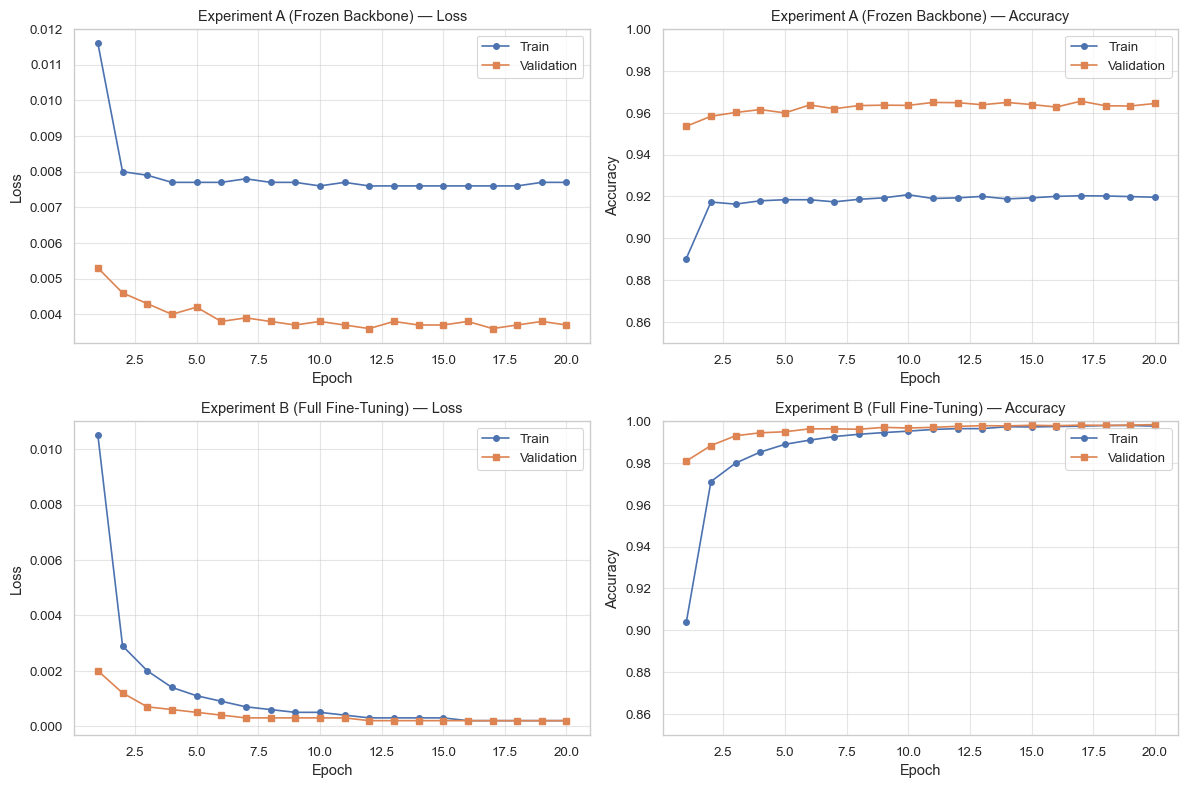

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\learning_curves.png


In [3]:
# --- Figure 1: Learning curves ---
# 2x2 grid: rows = experiment (A, B), cols = metric (loss, accuracy)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs = np.arange(1, 21)

# --- Row 1: Experiment A ---
axes[0, 0].plot(epochs, history_a['train_loss'], label='Train', marker='o', markersize=4)
axes[0, 0].plot(epochs, history_a['val_loss'],   label='Validation', marker='s', markersize=4)
axes[0, 0].set_title('Experiment A (Frozen Backbone) — Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(epochs, history_a['train_acc'], label='Train', marker='o', markersize=4)
axes[0, 1].plot(epochs, history_a['val_acc'],   label='Validation', marker='s', markersize=4)
axes[0, 1].set_title('Experiment A (Frozen Backbone) — Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].legend()

# --- Row 2: Experiment B ---
axes[1, 0].plot(epochs, history_b['train_loss'], label='Train', marker='o', markersize=4)
axes[1, 0].plot(epochs, history_b['val_loss'],   label='Validation', marker='s', markersize=4)
axes[1, 0].set_title('Experiment B (Full Fine-Tuning) — Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

axes[1, 1].plot(epochs, history_b['train_acc'], label='Train', marker='o', markersize=4)
axes[1, 1].plot(epochs, history_b['val_acc'],   label='Validation', marker='s', markersize=4)
axes[1, 1].set_title('Experiment B (Full Fine-Tuning) — Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0.85, 1.0)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "learning_curves.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'learning_curves.png'}")

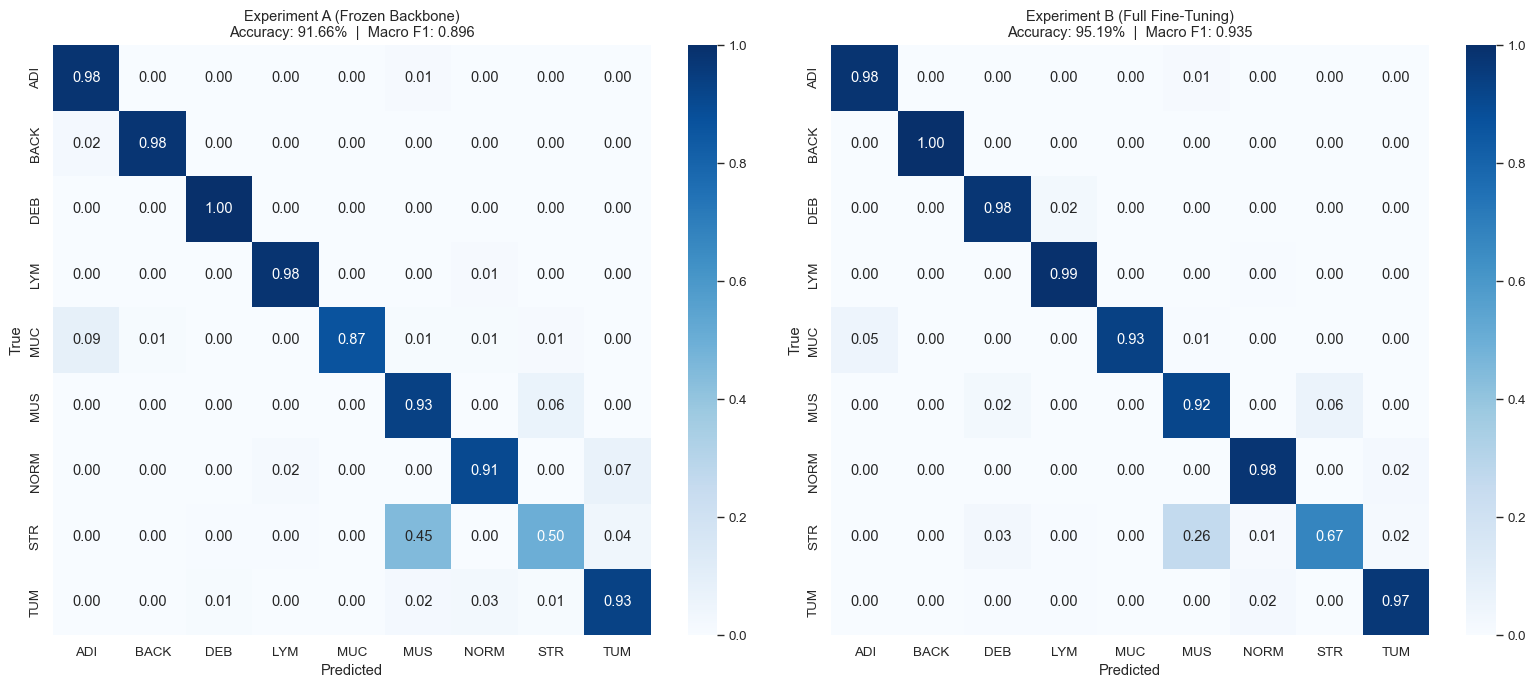

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\confusion_matrices_sidebyside.png


In [4]:
# --- Figure 2: Confusion matrices side-by-side (row-normalized) ---

# Row-normalize both so they're directly comparable
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Shared color scale (0 to 1) so shading is directly comparable
sns.heatmap(
    cm_a_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0, vmax=1, cbar=True, ax=axes[0],
)
axes[0].set_title("Experiment A (Frozen Backbone)\nAccuracy: 91.66%  |  Macro F1: 0.896")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_b_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0, vmax=1, cbar=True, ax=axes[1],
)
axes[1].set_title("Experiment B (Full Fine-Tuning)\nAccuracy: 95.19%  |  Macro F1: 0.935")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices_sidebyside.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'confusion_matrices_sidebyside.png'}")

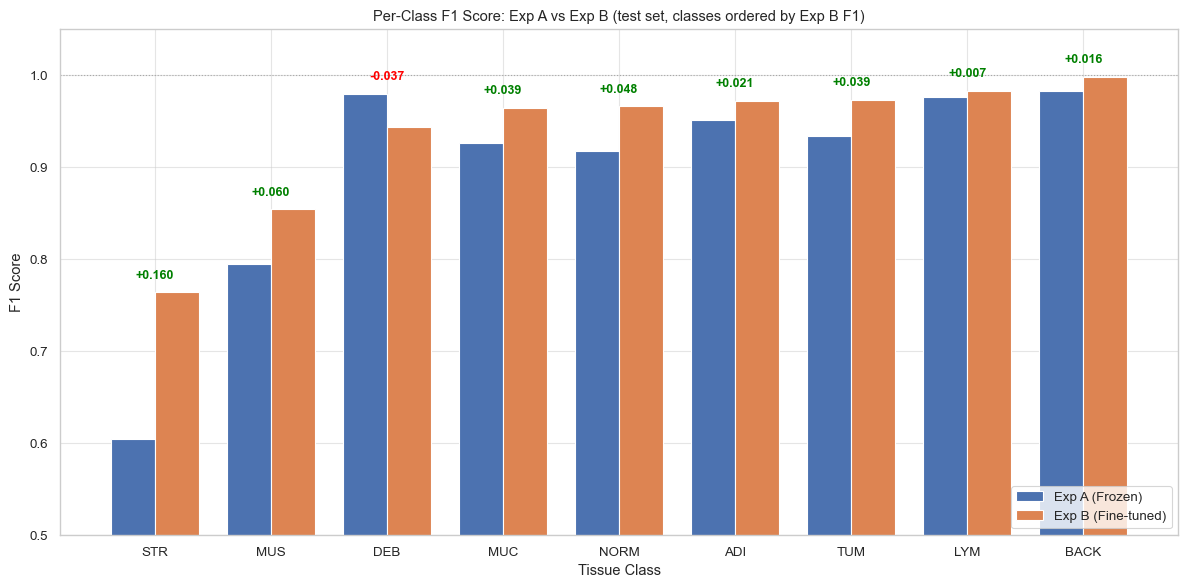

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\per_class_f1.png


In [5]:
# --- Figure 3: Per-class F1 bar chart ---
# Per-class F1 values from the classification reports (already computed)
f1_a = [0.9511, 0.9822, 0.9798, 0.9757, 0.9257, 0.7940, 0.9179, 0.6043, 0.9340]
f1_b = [0.9719, 0.9982, 0.9430, 0.9828, 0.9646, 0.8538, 0.9660, 0.7638, 0.9731]

# Sort classes by Exp B F1 ascending — worst-performing class ends up on the left
order = np.argsort(f1_b)
classes_sorted = [CLASS_NAMES[i] for i in order]
f1_a_sorted = [f1_a[i] for i in order]
f1_b_sorted = [f1_b[i] for i in order]
deltas      = [f1_b_sorted[i] - f1_a_sorted[i] for i in range(len(order))]

x     = np.arange(len(classes_sorted))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars_a = ax.bar(x - width/2, f1_a_sorted, width, label='Exp A (Frozen)', color='#4C72B0')
bars_b = ax.bar(x + width/2, f1_b_sorted, width, label='Exp B (Fine-tuned)', color='#DD8452')

# Annotate delta above each pair
for i, delta in enumerate(deltas):
    y_pos   = max(f1_a_sorted[i], f1_b_sorted[i]) + 0.015
    color   = 'green' if delta > 0 else 'red'
    ax.text(i, y_pos, f'{delta:+.3f}', ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Tissue Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score: Exp A vs Exp B (test set, classes ordered by Exp B F1)')
ax.set_xticks(x)
ax.set_xticklabels(classes_sorted)
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_class_f1.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'per_class_f1.png'}")


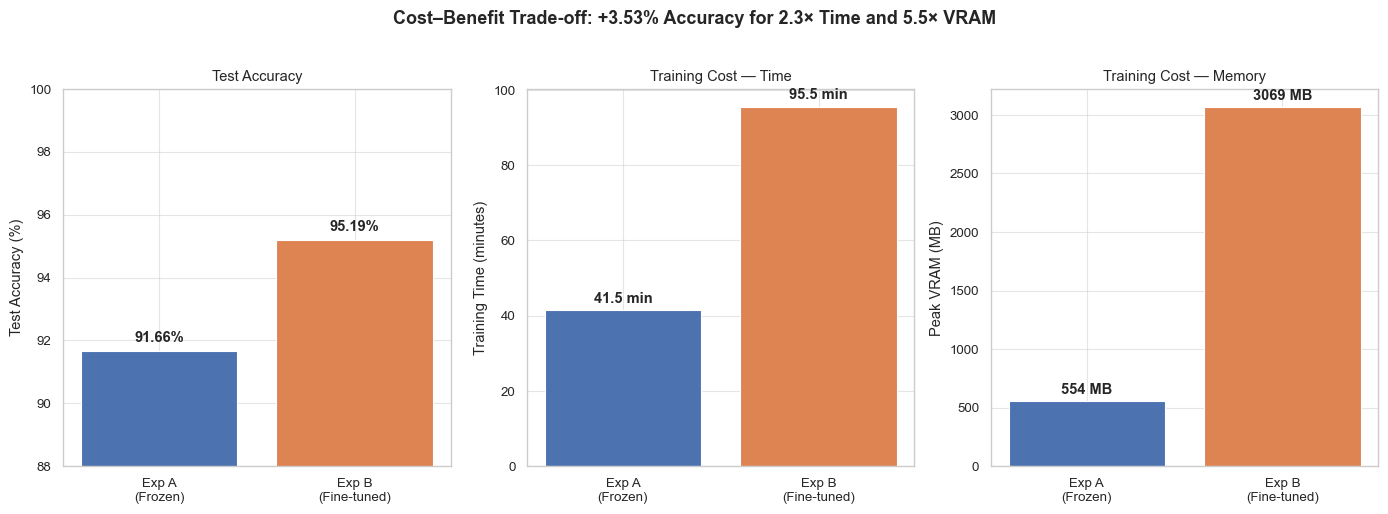

Saved: C:\Users\Frank\PycharmProjects\BIOE 486 Applied Deep Learning\Final_Project\outputs\figures\cost_benefit.png


In [6]:
# --- Figure 4: Cost-benefit comparison (accuracy vs compute) ---
# Headline accuracy, training time, and peak VRAM from your training runs

experiments = ['Exp A\n(Frozen)', 'Exp B\n(Fine-tuned)']

test_acc       = [91.66,   95.19]
training_time  = [41.5,    95.5]    # minutes
peak_vram      = [554.4,   3069.4]  # MB

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Test accuracy
axes[0].bar(experiments, test_acc, color=['#4C72B0', '#DD8452'])
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(88, 100)
for i, v in enumerate(test_acc):
    axes[0].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

# Training time
axes[1].bar(experiments, training_time, color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Cost — Time')
for i, v in enumerate(training_time):
    axes[1].text(i, v + 2, f'{v:.1f} min', ha='center', fontweight='bold')

# Peak VRAM
axes[2].bar(experiments, peak_vram, color=['#4C72B0', '#DD8452'])
axes[2].set_ylabel('Peak VRAM (MB)')
axes[2].set_title('Training Cost — Memory')
for i, v in enumerate(peak_vram):
    axes[2].text(i, v + 60, f'{v:.0f} MB', ha='center', fontweight='bold')

plt.suptitle('Cost–Benefit Trade-off: +3.53% Accuracy for 2.3× Time and 5.5× VRAM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cost_benefit.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'cost_benefit.png'}")


In [7]:
# --- Summary Table: Headline numbers for the report ---

# Values sourced from Asana / vault notes / evaluation script output
summary_rows = [
    ("Best val accuracy",     f"{max(history_a['val_acc'])*100:.2f}%",  f"{max(history_b['val_acc'])*100:.2f}%",  f"{(max(history_b['val_acc']) - max(history_a['val_acc']))*100:+.2f} pp"),
    ("Test accuracy",         "91.66%",                                  "95.19%",                                  "+3.54 pp"),
    ("Val → test drop",       "-4.89 pp",                                "-4.64 pp",                                "—"),
    ("Macro F1 (test)",       "0.8961",                                  "0.9353",                                  "+0.0392"),
    ("Weighted F1 (test)",    "0.9150",                                  "0.9512",                                  "+0.0362"),
    ("Training time",         "41.5 min",                                "95.5 min",                                "2.3×"),
    ("Peak VRAM",             "554 MB",                                  "3069 MB",                                 "5.5×"),
    ("Best epoch",            "17",                                      "20",                                      "—"),
    ("Worst class (F1)",      "STR (0.6043)",                            "STR (0.7638)",                            "+0.160"),
    ("Largest regression",    "—",                                       "DEB (-0.037)",                            "—"),
]

# Pretty-print as a clean table
col_widths = [24, 16, 16, 14]
header = ("Metric", "Exp A", "Exp B", "Delta")

print(f"{header[0]:<{col_widths[0]}}{header[1]:<{col_widths[1]}}{header[2]:<{col_widths[2]}}{header[3]:<{col_widths[3]}}")
print("-" * sum(col_widths))
for row in summary_rows:
    print(f"{row[0]:<{col_widths[0]}}{row[1]:<{col_widths[1]}}{row[2]:<{col_widths[2]}}{row[3]:<{col_widths[3]}}")

Metric                  Exp A           Exp B           Delta         
----------------------------------------------------------------------
Best val accuracy       96.55%          99.83%          +3.28 pp      
Test accuracy           91.66%          95.19%          +3.54 pp      
Val → test drop         -4.89 pp        -4.64 pp        —             
Macro F1 (test)         0.8961          0.9353          +0.0392       
Weighted F1 (test)      0.9150          0.9512          +0.0362       
Training time           41.5 min        95.5 min        2.3×          
Peak VRAM               554 MB          3069 MB         5.5×          
Best epoch              17              20              —             
Worst class (F1)        STR (0.6043)    STR (0.7638)    +0.160        
Largest regression      —               DEB (-0.037)    —             
